initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f88fd4e0df0> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

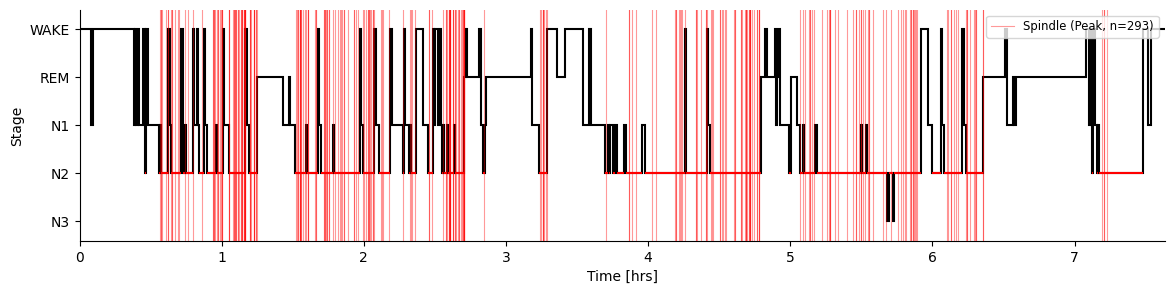

In [ ]:
from infraslow import BioserenityPSGLoader, BIOSERENITY_ALIAS_MAP
from infraslow.processing.signal import make_resampling_signal_reader
from infraslow.processing.detection import spindles_detect
from infraslow.io import make_hypnodensity_annotation_loader
from infraslow.viz import plot_spectrogram, plot_hypnogram, plot_spindles

import matplotlib.pyplot as plt

loader = BioserenityPSGLoader(
    subject_id="318679",
    sf=128,
    requested_channels=["F3", "F4", "C3", "C4", "O1", "O2"]
).load()
# loader.data

fig, ax = plt.subplots(figsize=(14, 3))
sp = spindles_detect(loader, ch_names="C3", include=(2,))
plot_hypnogram(loader, spindles=sp, highlight="N2", ax=ax);
# fig = plot_spectrogram(loader, channel="C3", hypno=True, fmax=30)

In [2]:
sp.summary().round(3)

,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,2038.273,2038.609,2038.984,0.711,71.654,36.045,14.571,2.298,0.299,12.600,8.0,0.467,2,C3,0
1,2071.297,2071.391,2071.836,0.539,37.554,26.544,8.384,1.929,0.320,12.295,7.0,0.171,2,C3,0
2,2075.438,2076.078,2076.328,0.891,43.876,24.578,9.591,1.855,0.287,13.485,9.0,0.713,2,C3,0
3,2079.109,2079.695,2079.844,0.734,34.774,22.091,8.645,1.670,0.256,13.318,9.0,0.789,2,C3,0
4,2194.758,2195.336,2195.938,1.180,51.729,23.035,8.788,1.512,0.230,12.773,13.0,0.487,2,C3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,22878.867,22879.234,22879.375,0.508,42.757,26.721,9.989,2.086,0.309,12.644,6.0,0.712,2,C3,0
289,25904.047,25904.141,25905.273,1.227,40.461,20.422,8.091,1.731,0.303,12.860,12.0,0.076,2,C3,0
290,25934.281,25934.602,25934.789,0.508,32.559,19.238,8.427,1.838,0.226,13.759,6.0,0.621,2,C3,0
291,25940.211,25940.367,25941.531,1.320,65.408,32.800,11.913,1.753,0.287,12.237,16.0,0.118,2,C3,0


In [3]:
sp.summary(grp_chan=True, grp_stage=True, aggfunc='mean')

,,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,Channel,,,,,,,,,,,
2,C3,293,1.279476,0.756586,54.565317,30.666051,11.792738,2.084095,0.356724,13.09727,9.273038,0.500991


In [4]:
sp.summary(grp_chan=False, grp_stage=True, aggfunc='median').round(3)

,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,,,,,,,,,,,
2,293,1.279,0.711,53.859,29.315,11.396,2.078,0.338,13.092,9.0,0.512


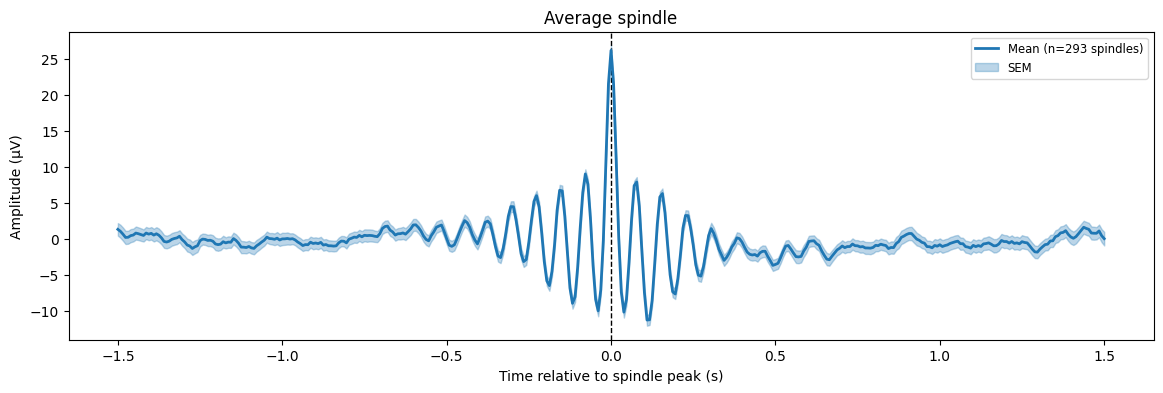

In [5]:
# sp.plot_average(errorbar='ci', palette="Set1");
fig, ax = plt.subplots(figsize=(14, 4));
plot_spindles(sp, errorbar="sem", show_events=False, ax=ax);

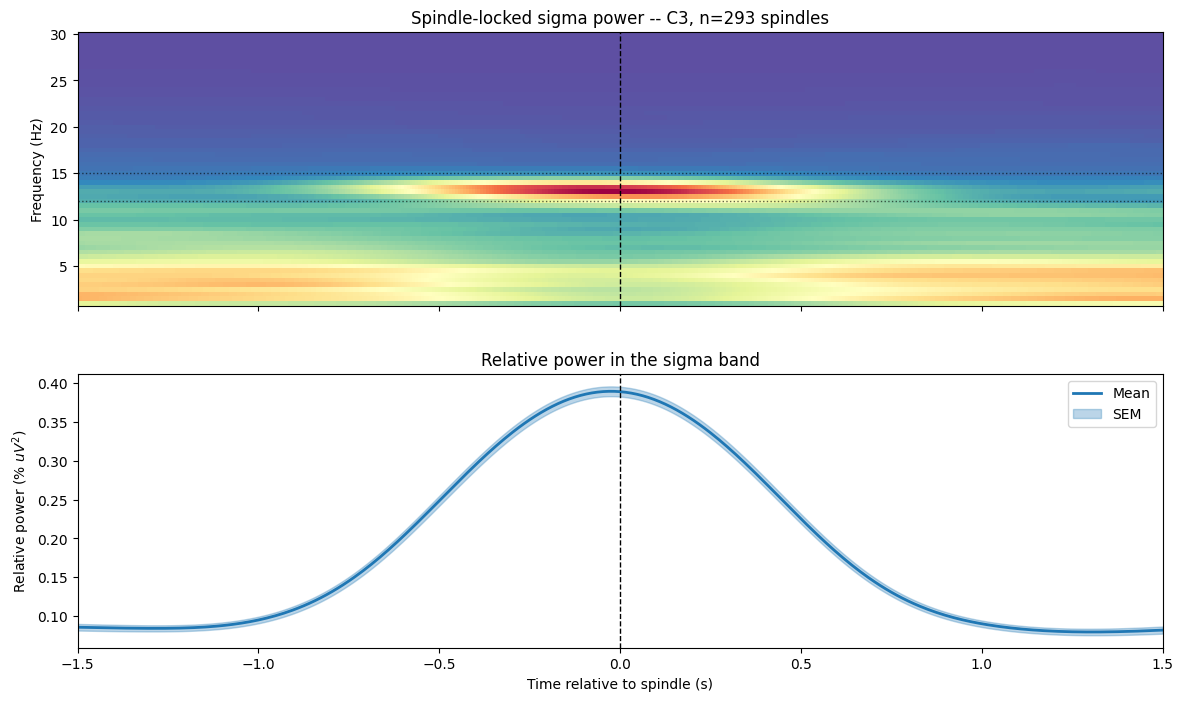

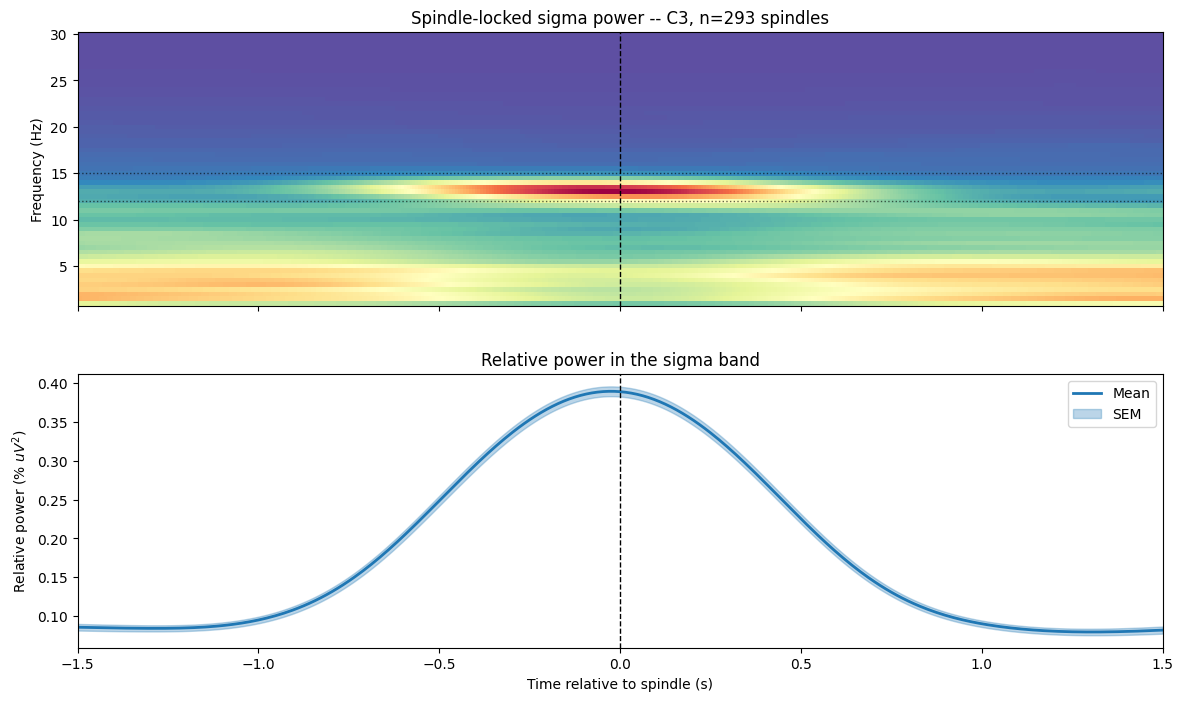

In [6]:
from infraslow.viz import plot_spindle_sigma_power
# one subject
plot_spindle_sigma_power(loader, sp)

## Multiple subjects: detect, summarize, and plot

Run spindle detection per subject, then aggregate as **average of all events in each subject, then mean across subjects**.

In [7]:
from infraslow import BioserenityPSGLoader, BIOSERENITY_ALIAS_MAP
# from infraslow.io import make_hypnodensity_annotation_loader
from infraslow.processing.detection import (
    detect_subjects_spindles,
    aggregate_spindle_summaries,
)
from infraslow.viz import plot_spindles_grand_average

subject_ids = ["318679", "318769", "318919"]

# Build one loader per subject (resampled to 128 Hz, with the hypnodensity
# hypnogram attached). Constructing the loaders is now the caller's job, which
# decouples loading from detection.
# annotation_loader = make_hypnodensity_annotation_loader()
loaders = [
    BioserenityPSGLoader(
        subject_id=sid,
        # alias_map=BIOSERENITY_ALIAS_MAP,
        sf=128,
        # annotation_loader=annotation_loader,
        requested_channels=["C3"],
    )
    for sid in subject_ids
]

# detect_subjects_spindles loads each loader (if needed) and detects spindles on
# C3 in N2; it reads loader.sf automatically.
results = detect_subjects_spindles(loaders, channel="C3", include=(2,))

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f88fd4e0df0> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

Subject 318679: 293 spindle(s) detected on C3.
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f88fd4e0df0> 



___________________________________________________________________
Processing: 318769 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318769.edf
 duration 07.48.36, 28116s | time 22.08.01 - 05.56.37 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
29-Jun-26 15:00:28 | WARNING | Hypnogram is SHORTER than data by 6.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 318769: 50 spindle(s) detected on C3.
initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f88fd4e0df0> 



___________________________________________________________________
Processing: 318919 | /oak/stanford/groups/mignot/psg/Bioserenity/edf/318919.edf
 duration 07.27.23, 26843s | time 22.35.46 - 06.03.09 | date 01.01.12

 signals: 29 (of 29) selected in an EDF+C file
  F3 | F4 | C3 | C4 | O1 | O2 | LOC | ROC
  ECG | emg_Chin | emg_RLeg | emg_LLeg | Tho | Abd | SpO2 | flow_PFlo
  flow_TFlo | flow_CFlo | PPG | Snore | imp | rr | Leak | EPAP
  IPAP | Body | sao2 | HR | EDF Annotations
  extracting 'EDF Annotations' track from EDF+
29-Jun-26 15:00:37 | WARNING | Hypnogram is SHORTER than data by 23.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Subject 318919: 527 spindle(s) detected on C3.


In [8]:
# Per subject: the mean of all its detected events (Count, Density,
# Duration, Amplitude, Frequency, ...). One row per subject.
per_subject, grand_mean = aggregate_spindle_summaries(results)
per_subject.round(3)

,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
subject_id,,,,,,,,,,,
318679,293.0,1.279,0.757,54.565,30.666,11.793,2.084,0.357,13.097,9.273,0.501
318769,50.0,0.177,0.718,46.149,21.894,9.229,1.840,0.315,13.072,8.880,0.552
318919,527.0,2.395,0.896,50.693,29.030,11.093,2.035,0.379,12.867,11.051,0.502


In [9]:
# Grand summary: mean of the per-subject rows (every subject weighted equally).
grand_mean.round(3)

Count           290.000
Density           1.284
Duration          0.790
Amplitude        50.469
AmpFiltered      27.197
RMS              10.705
AbsPower          1.986
RelPower          0.350
Frequency        13.012
Oscillations      9.735
Symmetry          0.518
Name: mean_of_3_subjects, dtype: float64

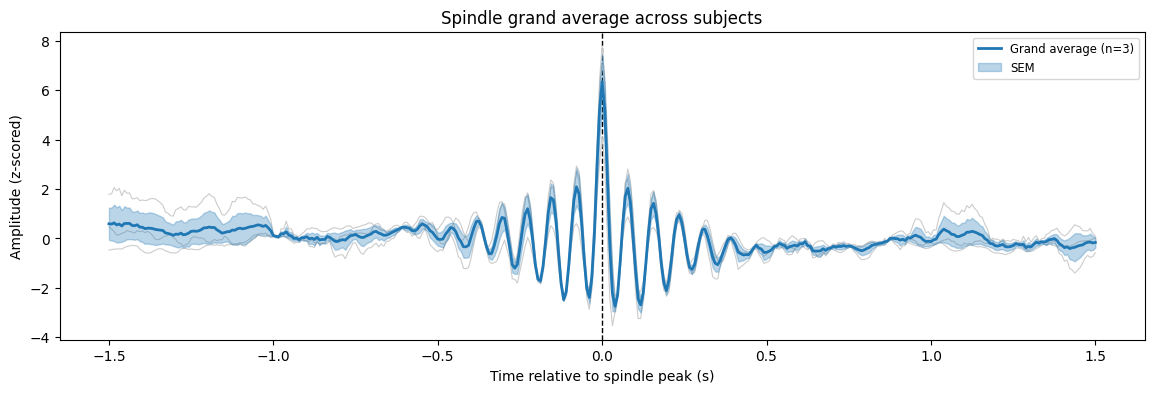

In [10]:
# Grand-average waveform: each subject's mean spindle, averaged across
# subjects (shaded band = SEM across subjects; grey = individual subjects).
fig, ax = plt.subplots(figsize=(14, 4))
plot_spindles_grand_average(results, normalize=True, errorbar="sem", ax=ax);

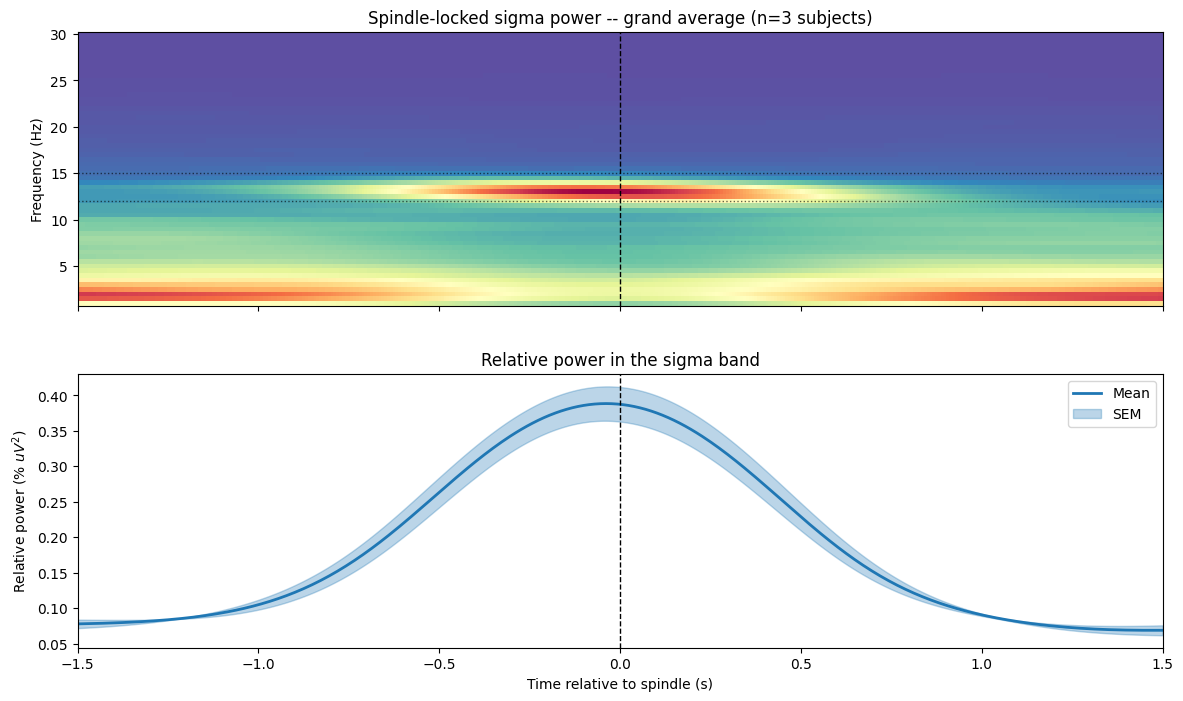

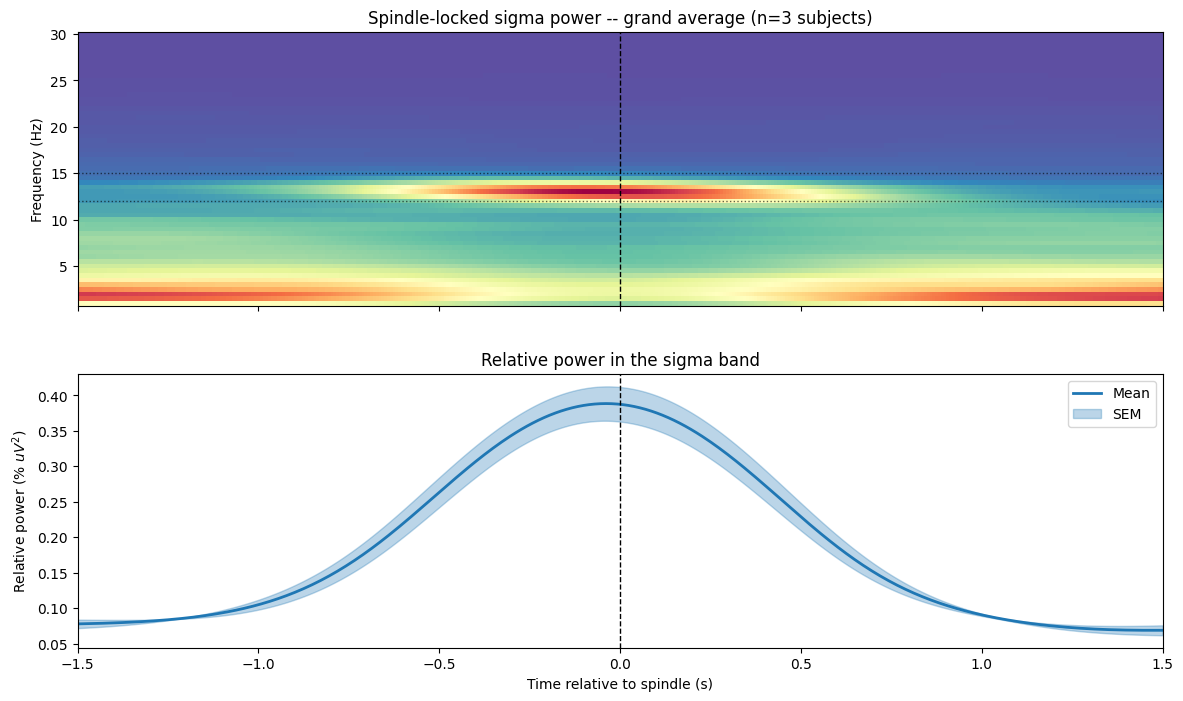

In [11]:
from infraslow.viz import  plot_spindles_sigma_power_grand_average

plot_spindles_sigma_power_grand_average(zip(loaders, results.values()))